In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import StudentT

import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [2]:
def g(x):
    """
    Initial condition
    """
    return - torch.sin(torch.pi*x)

[Gauss_pts, weights] = np.polynomial.hermite.hermgauss(80)

def u_true(t, x, nv):
    temp = x-np.sqrt(4*nv*t)*Gauss_pts
    val1 = weights * np.sin(np.pi*temp) * np.exp(-np.cos(np.pi*temp)/(2*np.pi*nv))
    val2 = weights * np.exp(-np.cos(np.pi*temp)/(2*np.pi*nv))
    return -np.sum(val1)/np.sum(val2)

In [3]:
class BurgersRF(nn.Module):

    def __init__(self, Nx, Nt, sigma_x=1.0, sigma_t=1.0, df_x=1, df_t=1, x_dist = 'Gaussian', t_dist = 'Gaussian'):

        super(BurgersRF, self).__init__()

        if x_dist == 'Gaussian':
            self.Wx = nn.Parameter(torch.randn(1, Nx) / sigma_x, requires_grad=False).to(device)
        elif x_dist == 'Student':
            dist = torch.distributions.StudentT(df=df_x, loc=0.0, scale=sigma_x)
            self.Wx = nn.Parameter(dist.sample((1, Nx)), requires_grad=False).to(device)

        if t_dist == 'Gaussian':
            self.Wt = nn.Parameter(torch.randn(1, Nt) / sigma_t, requires_grad=False).to(device)
        elif t_dist == 'Student':
            dist = torch.distributions.StudentT(df=df_t, loc=0.0, scale=sigma_t)
            self.Wt = nn.Parameter(dist.sample((1, Nt)), requires_grad=False).to(device)

        # bias
        self.bx = nn.Parameter(torch.rand(Nx) * 2 * torch.pi, requires_grad=False).to(device)
        self.bt = nn.Parameter(torch.rand(Nt) * 2 * torch.pi, requires_grad=False).to(device)

        self.model = nn.Sequential(nn.Linear(Nx * Nt, 1, bias=False))

    def forward(self, x, t):

        phi_x = torch.cos(x @ self.Wx + self.bx).to(device)
        phi_t = torch.cos(t @ self.Wt + self.bt).to(device)

        result_einsum = torch.einsum('bi,bj->bij', phi_x, phi_t).reshape(phi_x.shape[0], phi_x.shape[1] * phi_t.shape[1]).to(device)

        u = self.model(result_einsum)
        return u


def loss_fn(model, x, t, m_bd, m_int, nv, g):
    """
    Compute the PINN loss
    """

    # interior:
    u = model(x, t)

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    residual = u_t + u * u_x - nv * u_xx

    # boundary
    t_bd = torch.rand(m_bd, 1).to(device)
    x_left = - torch.ones(t_bd.shape).to(device)
    x_right = torch.ones(t_bd.shape).to(device)
    u_bd1 = model(x_left, t_bd)
    u_bd2 = model(x_right, t_bd)
    residual_bd = torch.concat((u_bd1, u_bd2))

    # initial
    x_int = 2 * torch.rand(m_int, 1) - 1
    x_int = x_int.to(device)
    t_int = torch.zeros(x_int.shape)
    t_int = t_int.to(device)
    u_int = model(x_int, t_int)
    residual_int = u_int - g(x_int).reshape(u_int.shape)

    return torch.mean(residual**2) + torch.Tensor([1e3]).to(device) * (torch.mean(residual_int**2) + torch.mean(residual_bd**2))

def train(model, optimizer, x, t, m_bd, m_int, nv, g, epochs=1000):

    losses = []
    for epoch in range(epochs):

        optimizer.zero_grad()
        loss = loss_fn(model, x, t, m_bd, m_int, nv, g)
        loss.backward(retain_graph=True)
        optimizer.step()
        losses.append(loss.item())
        if epoch % 1000 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
    return losses

In [4]:
# Define parameters and synthetic data
m_train = 3600
#nv = 0.02
nv = 0.01 / np.pi
x_train = 2 * torch.rand(m_train, 1, requires_grad=True) - 1
x_train = x_train.to(device)
t_train = torch.rand(m_train, 1, requires_grad=True)
t_train = t_train.to(device)

# boundary
m_bd = 500

# initial condition
m_int = 500

# test samples at uniform grids
m_test = 100
x_test = torch.linspace(-1,1,m_test)
t_test = torch.linspace(0,1,10)
x_t_product = torch.cartesian_prod(t_test, x_test)
x_test = x_t_product[:,[1]].to(device)
t_test = x_t_product[:,[0]].to(device)

# true function values at test points
y_true = [u_true(t_test.cpu().detach().numpy()[i], x_test.cpu().detach().numpy()[i], nv) for i in range(x_test.shape[0])]
y_true = np.array(y_true)

In [ ]:
# Model 1: Gaussian x and Gaussian t
# initialize model and optimizer
Nx = 500
Nt = 10

sigma_x = 1/25
sigma_t = 1/3

errors = []
T = 10

for _ in range(T):
    model = BurgersRF(Nx, Nt, sigma_x, sigma_t).to(device)
    optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1)

    # Train the model
    losses = train(model, optimizer, x_train, t_train, m_bd, m_int, nv, g, epochs=5000)

    y_pred = model(x_test, t_test)
    y_pred = y_pred.cpu().detach().numpy().reshape(-1)
#print(y_true.shape, y_pred.shape)
    e = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)
    errors.append(e)

print(errors)
print(np.mean(errors))

Epoch 0, Loss: 687.4547714604896
Epoch 1000, Loss: 0.09638468735735241
Epoch 2000, Loss: 0.0681617124675336
Epoch 3000, Loss: 0.09891308519124364
Epoch 4000, Loss: 1.1239671479806517
Epoch 0, Loss: 663.9559570734784
Epoch 1000, Loss: 0.08914446356143599
Epoch 2000, Loss: 0.041654065012908054
Epoch 3000, Loss: 0.026768794973489256
Epoch 4000, Loss: 0.09022255871741083
Epoch 0, Loss: 787.448203202525
Epoch 1000, Loss: 0.39778283089136873
Epoch 2000, Loss: 0.08750710067964482
Epoch 3000, Loss: 0.19258296295408056
Epoch 4000, Loss: 0.5105716841551735
Epoch 0, Loss: 724.9518978252196
Epoch 1000, Loss: 0.10071369674380196
Epoch 2000, Loss: 0.03125739671947219
Epoch 3000, Loss: 0.05633726797230186
Epoch 4000, Loss: 3.171188919739856
Epoch 0, Loss: 720.4778097940847
Epoch 1000, Loss: 0.1332843990733978
Epoch 2000, Loss: 0.07261359753056545
Epoch 3000, Loss: 0.03651319480402168
Epoch 4000, Loss: 0.03489550841931461
Epoch 0, Loss: 641.7567503251288
Epoch 1000, Loss: 0.07435968830476847
Epoch 200

In [ ]:
# Model 3: Gaussian x and Student t
# initialize model and optimizer
Nx = 100
Nt = 40
df_t = 5
sigma_x = 1/25
sigma_t = 3

errors = []
T = 10

for _ in range(T):
    model = BurgersRF(Nx, Nt, sigma_x, sigma_t, df_x=1, df_t = df_t, x_dist='Gaussian', t_dist = 'Student').to(device)
    optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1)
    # Train the model
    losses = train(model, optimizer, x_train, t_train, m_bd, m_int, nv, g, epochs=5000)

    y_pred = model(x_test, t_test)
    y_pred = y_pred.cpu().detach().numpy().reshape(-1)
#print(y_true.shape, y_pred.shape)
    e = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)
    errors.append(e)

print(" ")
print(errors)
print(" ")
print(np.mean(errors))

Epoch 0, Loss: 682.2210912160159
Epoch 1000, Loss: 0.3281784932463689
Epoch 2000, Loss: 0.05818226130395167
Epoch 3000, Loss: 0.2100684383122804
Epoch 4000, Loss: 0.06535940769012066
Epoch 0, Loss: 724.779486687812
Epoch 1000, Loss: 0.03652969781793819
Epoch 2000, Loss: 0.026939944591640994
Epoch 3000, Loss: 0.06531276918136723
Epoch 4000, Loss: 0.025361551596467705
Epoch 0, Loss: 682.4181224681932
Epoch 1000, Loss: 0.04840056583886089
Epoch 2000, Loss: 0.19382086253728661
Epoch 3000, Loss: 0.10174032774242969
Epoch 4000, Loss: 0.1397913252741188
Epoch 0, Loss: 554.1878983520052
Epoch 1000, Loss: 0.05080189741968177
Epoch 2000, Loss: 0.04045563448516879
Epoch 3000, Loss: 0.28451345512975673
Epoch 4000, Loss: 0.05656820776589329
Epoch 0, Loss: 930.3587562335427
Epoch 1000, Loss: 0.04709545625066995
Epoch 2000, Loss: 0.02555158429441856
Epoch 3000, Loss: 0.02255080388623642
Epoch 4000, Loss: 0.021438263210838394
Epoch 0, Loss: 931.4234960935617
Epoch 1000, Loss: 0.06493930059680197
Epoch

In [8]:
# Model 4: Student x and Student t
# initialize model and optimizer
Nx = 200
Nt = 20
sigma_x = 25
sigma_t = 3
df_x = 3
df_t = 1

errors = []
T = 10

for _ in range(T):
    model = BurgersRF(Nx, Nt, sigma_x, sigma_t, df_x=df_x, df_t = df_t, x_dist='Student', t_dist = 'Student').to(device)
    optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1)

    # Train the model
    losses = train(model, optimizer, x_train, t_train, m_bd, m_int, nv, g, epochs=5000)
    y_pred = model(x_test, t_test)
    y_pred = y_pred.cpu().detach().numpy().reshape(-1)
#print(y_true.shape, y_pred.shape)
    e = np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)
    errors.append(e)


print(" ")
print(errors)
print(" ")
print(np.mean(errors))

Epoch 0, Loss: 2437.6128899174983
Epoch 1000, Loss: 0.3586774225589637
Epoch 2000, Loss: 0.22778952968288776
Epoch 3000, Loss: 0.42638787286694396
Epoch 4000, Loss: 0.2159417094044219


KeyboardInterrupt: 

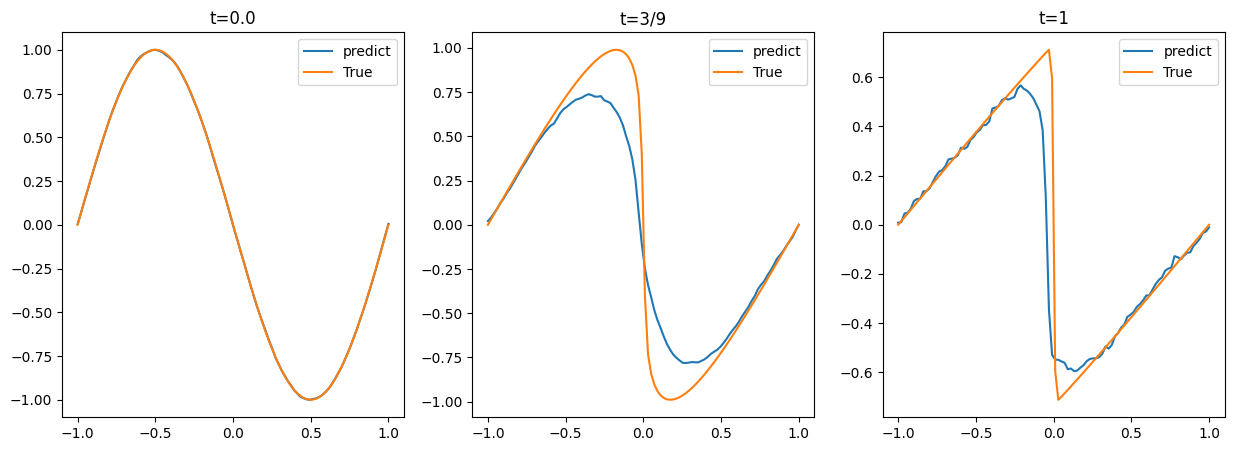

In [9]:
fig, ax = plt.subplots(1,3,figsize=(15,5))
ax[0].plot(x_test.cpu().detach().numpy()[:100], y_pred[:100], label='predict')
ax[0].plot(x_test.cpu().detach().numpy()[:100], y_true[:100], label='True')
ax[0].set_title('t=0.0')
ax[0].legend()

ax[1].plot(x_test.cpu().detach().numpy()[300:400], y_pred[300:400], label='predict')
ax[1].plot(x_test.cpu().detach().numpy()[300:400], y_true[300:400], label='True')
ax[1].set_title('t=3/9')
ax[1].legend()

ax[2].plot(x_test.cpu().detach().numpy()[900:], y_pred[900:], label='predict')
ax[2].plot(x_test.cpu().detach().numpy()[900:], y_true[900:], label='True')
ax[2].set_title('t=1')
ax[2].legend()